---
numbering: false
---

# 2.2: Orthonormal bases in ℝ²

In [1]:
import numpy as np
import plotly.graph_objects as go
from pathlib import Path
import sys

_notes_root = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'myst.yml').exists())
if str(_notes_root) not in sys.path:
    sys.path.insert(0, str(_notes_root))
from plot_style import style_plotly

BLUE, ORANGE, PINK = '#3d81f6', 'orange', '#d81a60'


def base2(xrange=(-5, 6), yrange=(-5, 5), width=700, height=580, tick=1):
    fig = style_plotly(go.Figure(), renderer='png')
    fig.update_layout(width=width, height=height, showlegend=False,
                      font=dict(size=17), margin=dict(l=55, r=30, t=30, b=50))
    fig.update_xaxes(title='x', range=xrange, dtick=tick, zeroline=True, zerolinewidth=1.5,
                     constrain='domain', scaleanchor='y', scaleratio=1)
    fig.update_yaxes(title='y', range=yrange, dtick=tick, zeroline=True, zerolinewidth=1.5,
                     constrain='domain')
    return fig


def line2(fig, start, end, color=BLUE, dash='solid', width=2):
    fig.add_trace(go.Scatter(x=[start[0], end[0]], y=[start[1], end[1]], mode='lines',
                            line=dict(color=color, width=width, dash=dash),
                            hoverinfo='skip', showlegend=False))


def label2(fig, xy, label, dx=0, dy=0):
    fig.add_annotation(x=float(xy[0])+dx, y=float(xy[1])+dy, text=label, showarrow=False,
                       font=dict(color='black', size=17))


def point2(fig, xy, label=None, dx=0.35, dy=0.35):
    fig.add_trace(go.Scatter(x=[xy[0]], y=[xy[1]], mode='markers',
                            marker=dict(color='black', size=7), hoverinfo='skip'))
    if label: label2(fig, xy, label, dx, dy)


def vec2(fig, end, label=None, color=BLUE, start=(0, 0), dx=0.25, dy=0.3, width=3):
    fig.add_annotation(x=float(end[0]), y=float(end[1]), ax=float(start[0]), ay=float(start[1]),
                       xref='x', yref='y', axref='x', ayref='y', showarrow=True,
                       text='', arrowhead=3, arrowsize=1.25, arrowwidth=width, arrowcolor=color)
    if label: label2(fig,end,label,dx,dy)


def square2(fig, corner, along, perp, size=0.3):
    corner=np.asarray(corner,dtype=float)
    u=np.asarray(along,dtype=float); u=u/np.linalg.norm(u)*size
    v=np.asarray(perp,dtype=float); v=v/np.linalg.norm(v)*size
    line2(fig,corner+u,corner+u+v,'gray',width=1.5)
    line2(fig,corner+v,corner+u+v,'gray',width=1.5)


def base3():
    fig=style_plotly(go.Figure(),renderer='plotly_mimetype')
    axis=dict(range=[-6,7],dtick=2,showbackground=True,showspikes=False)
    fig.update_layout(width=760,height=620,showlegend=False,font=dict(size=16),
                      margin=dict(l=0,r=0,t=15,b=0),
                      scene=dict(xaxis=dict(title='x',**axis),yaxis=dict(title='y',**axis),
                                 zaxis=dict(title='z',**axis),aspectmode='cube',
                                 camera=dict(eye=dict(x=1.6,y=-2.1,z=1.3))))
    for direction in np.eye(3):
        line3(fig,-6*direction,7*direction,'#9ca3af',width=2)
    return fig


def line3(fig,start,end,color=BLUE,width=5,dash='solid'):
    fig.add_trace(go.Scatter3d(x=[start[0],end[0]],y=[start[1],end[1]],z=[start[2],end[2]],
                              mode='lines',line=dict(color=color,width=width,dash=dash),
                              hoverinfo='skip',showlegend=False))


def vec3(fig,end,label,color=BLUE,start=(0,0,0),offset=(0.25,0.25,0.35)):
    start,end=np.asarray(start,float),np.asarray(end,float)
    direction=(end-start)/np.linalg.norm(end-start)
    line3(fig,start,end-0.15*direction,color,width=7)
    fig.add_trace(go.Cone(x=[end[0]],y=[end[1]],z=[end[2]],u=[direction[0]],v=[direction[1]],w=[direction[2]],
                         anchor='tip',sizemode='absolute',sizeref=0.45,colorscale=[[0,color],[1,color]],
                         showscale=False,hoverinfo='skip'))
    pos=end+offset
    fig.add_trace(go.Scatter3d(x=[pos[0]],y=[pos[1]],z=[pos[2]],mode='text',text=[label],
                              textfont=dict(color='black',size=16),hoverinfo='skip'))


def plane3(fig,normal,color=BLUE,opacity=0.24):
    # Solve n_x*x + n_y*y + n_z*z = 0 for y on a rectangular x,z mesh.
    x,z=np.meshgrid(np.linspace(-5,6,2),np.linspace(-5,6,2))
    n=np.asarray(normal,float)
    y=-(n[0]*x+n[2]*z)/n[1]
    fig.add_trace(go.Surface(x=x.tolist(),y=y.tolist(),z=z.tolist(),
                            colorscale=[[0,color],[1,color]],opacity=opacity,
                            showscale=False,hoverinfo='skip'))
    corners=np.array([[x[0,0],y[0,0],z[0,0]],[x[0,1],y[0,1],z[0,1]],
                      [x[1,1],y[1,1],z[1,1]],[x[1,0],y[1,0],z[1,0]]])
    for i in range(4): line3(fig,corners[i],corners[(i+1)%4],color,width=2)


In [Chapter 1.4](../ch01/01-04.ipynb), we wrote vectors as linear combinations of the standard basis vectors. Could we use a different pair of directions? In this section, we'll see why perpendicular unit vectors make this especially convenient.

## The standard basis

Recall the standard basis vectors from [Chapter 1.4](../ch01/01-04.ipynb):

$$
\vec e_1=
\begin{bmatrix}
1\\
0
\end{bmatrix},
\qquad
\vec e_2=
\begin{bmatrix}
0\\
1
\end{bmatrix}.
$$

What is nice about them is that every vector can be easily expressed as a
combination of them.

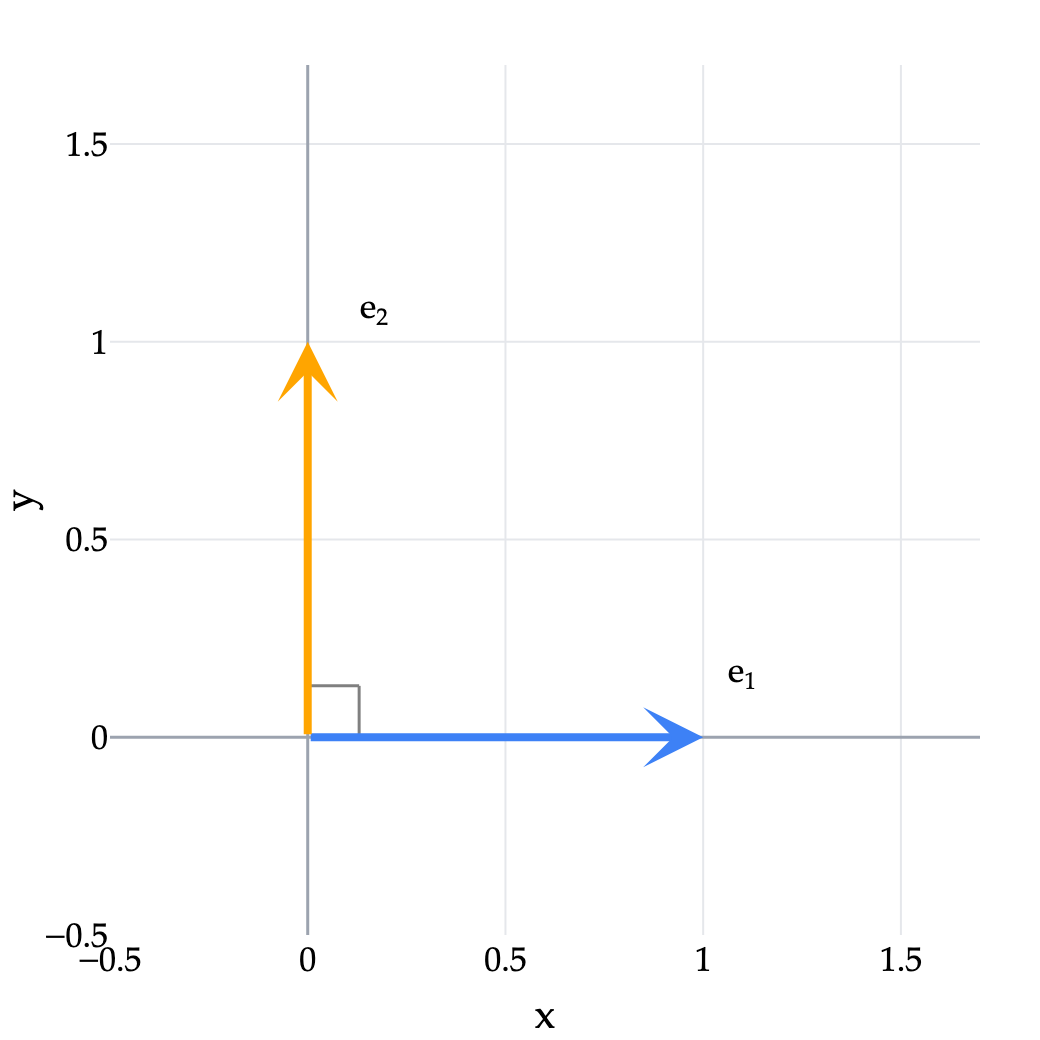

In [2]:
fig=base2((-0.5,1.7),(-0.5,1.7),width=520,height=520,tick=0.5)
vec2(fig,(1,0),'e<sub>1</sub>',BLUE,dx=0.1,dy=0.16,width=4)
vec2(fig,(0,1),'e<sub>2</sub>',ORANGE,dx=0.17,dy=0.08,width=4)
square2(fig,(0,0),(1,0),(0,1),0.13)
fig.show(scale=2)

The standard basis vectors in $\mathbb{R}^2$.

For example,

$$
\begin{bmatrix}
5\\
7
\end{bmatrix}
=
\begin{bmatrix}
5\\
0
\end{bmatrix}
+
\begin{bmatrix}
0\\
7
\end{bmatrix}
=
5
\begin{bmatrix}
1\\
0
\end{bmatrix}
+
7
\begin{bmatrix}
0\\
1
\end{bmatrix}
=
5\vec e_1+7\vec e_2.
$$

To do geometry in $\mathbb{R}^2$, it is useful to consider other such pairs of
vectors. The key properties of $(\vec e_1,\vec e_2)$ are:

1. length one,
1. orthogonal to each other.

We will now discuss the notion of an orthonormal basis.

Recall from [Chapter 1.5](../ch01/01-05.ipynb) that a **unit vector** has length one. We can turn any nonzero vector $\vec w$ into a unit vector by dividing by its length: $\vec w/\lVert\vec w\rVert$.

## Orthonormal bases

**Example.**

The vector

$$
\begin{bmatrix}
\frac45\\[2pt]
\frac35
\end{bmatrix}
$$

has length one since

$$
\sqrt{\left(\frac45\right)^2+\left(\frac35\right)^2}
=
\sqrt{\frac{16}{25}+\frac{9}{25}}
=
1.
$$

Similarly, the vector

$$
\begin{bmatrix}
\frac{1}{\sqrt{2}}\\[2pt]
-\frac{1}{\sqrt{2}}
\end{bmatrix}
$$

has length one since

$$
\sqrt{
\left(\frac{1}{\sqrt{2}}\right)^2+
\left(-\frac{1}{\sqrt{2}}\right)^2
}
=
\sqrt{\frac12+\frac12}
=
1.
$$

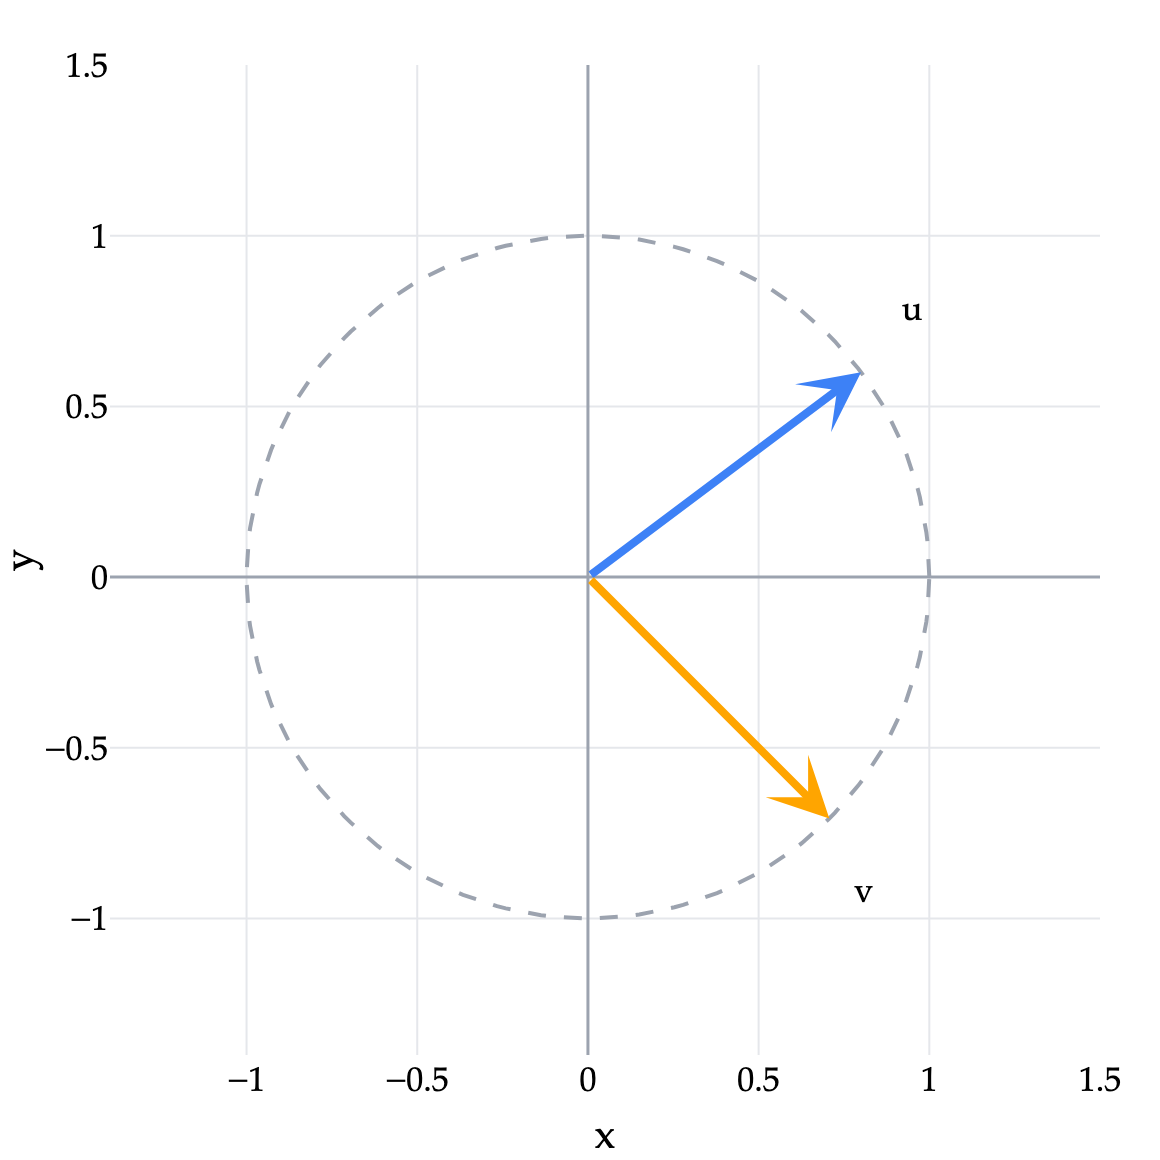

In [3]:
fig=base2((-1.4,1.5),(-1.4,1.5),width=580,height=580,tick=0.5)
t=np.linspace(0,2*np.pi,240)
fig.add_trace(go.Scatter(x=np.cos(t),y=np.sin(t),mode='lines',line=dict(color='#9ca3af',width=2,dash='dash'),hoverinfo='skip'))
vec2(fig,(4/5,3/5),'u',BLUE,dx=0.15,dy=0.18,width=4)
vec2(fig,(1/np.sqrt(2),-1/np.sqrt(2)),'v',ORANGE,dx=0.1,dy=-0.22,width=4)
fig.show(scale=2)

Examples of unit vectors in $\mathbb{R}^2$: $\vec u=\begin{bmatrix}4/5\\3/5\end{bmatrix}$ and $\vec v=\begin{bmatrix}1/\sqrt{2}\\-1/\sqrt{2}\end{bmatrix}$.

**Example.**

Let

$$
\vec u_1=
\begin{bmatrix}
\frac45\\[2pt]
\frac35
\end{bmatrix},
\qquad
\vec u_2=
\begin{bmatrix}
-\frac35\\[2pt]
\frac45
\end{bmatrix}.
$$

Both vectors have length one, and their dot product is

$$
\vec u_1\cdot\vec u_2=\frac45\left(-\frac35\right)+\frac35\left(\frac45\right)=0.
$$

By [Chapter 1.6](../ch01/01-06.ipynb), they are orthogonal. This pair is an **orthonormal basis** of $\mathbb R^2$.

:::{note} Definition: Orthonormal basis in $\mathbb R^2$
An **orthonormal basis** of $\mathbb R^2$ is a pair of unit vectors that are orthogonal to each other.
:::

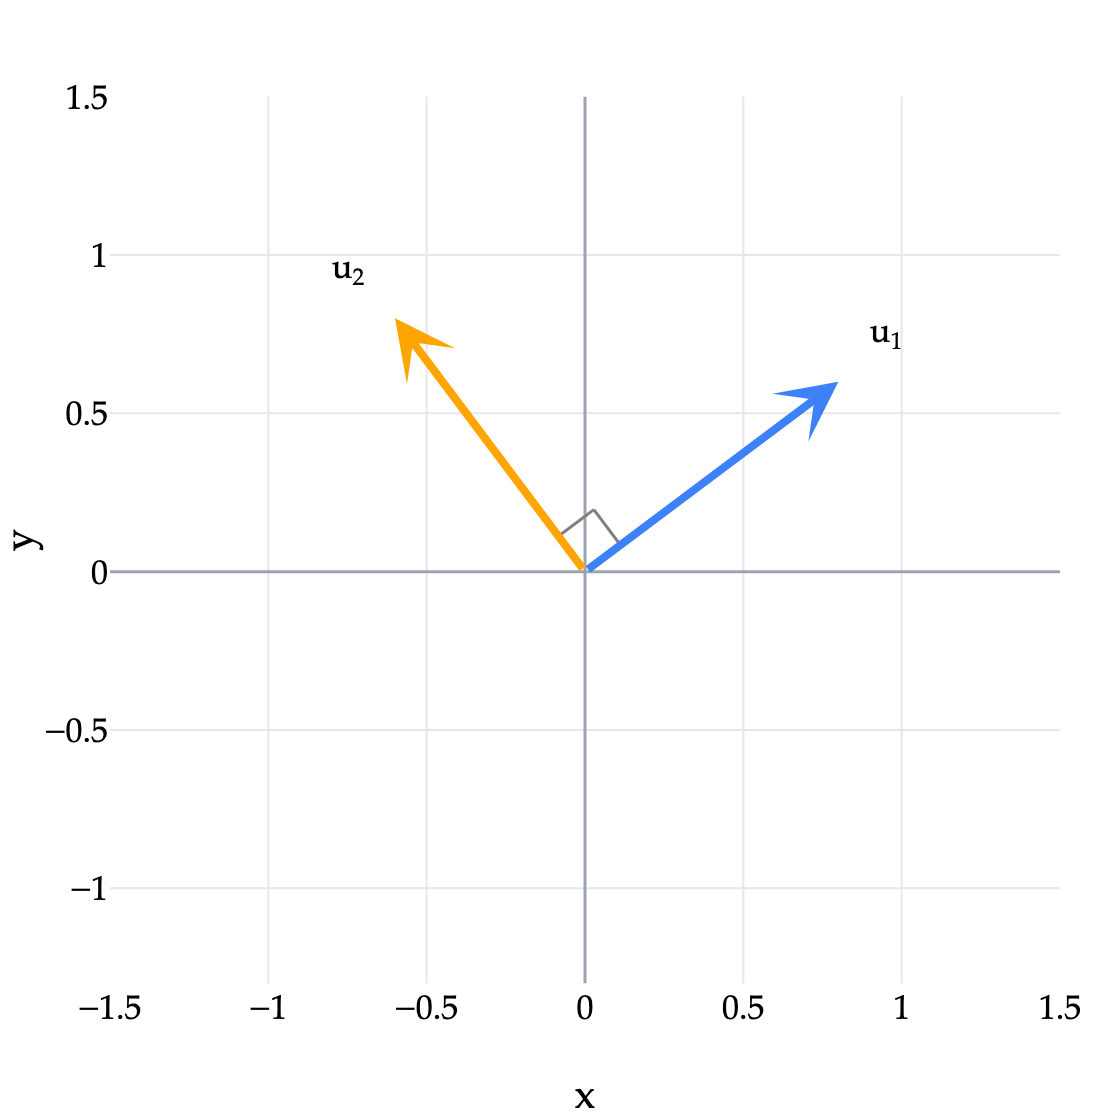

In [4]:
fig=base2((-1.5,1.5),(-1.3,1.5),width=560,height=560,tick=0.5)
u1=np.array([4/5,3/5]); u2=np.array([-3/5,4/5])
vec2(fig,u1,'u<sub>1</sub>',BLUE,dx=0.15,dy=0.15,width=4)
vec2(fig,u2,'u<sub>2</sub>',ORANGE,dx=-0.15,dy=0.15,width=4)
square2(fig,(0,0),u1,u2,0.14)
fig.show(scale=2)

The pair $(\vec u_1,\vec u_2)$ is an orthonormal basis of $\mathbb{R}^2$.

**Example.**

Let

$$
\vec w_1=
\begin{bmatrix}
-\frac{1}{\sqrt{2}}\\[2pt]
\frac{1}{\sqrt{2}}
\end{bmatrix},
\qquad
\vec w_2=
\begin{bmatrix}
-\frac{1}{\sqrt{2}}\\[2pt]
-\frac{1}{\sqrt{2}}
\end{bmatrix}.
$$

Then $(\vec w_1,\vec w_2)$ is also an orthonormal basis.

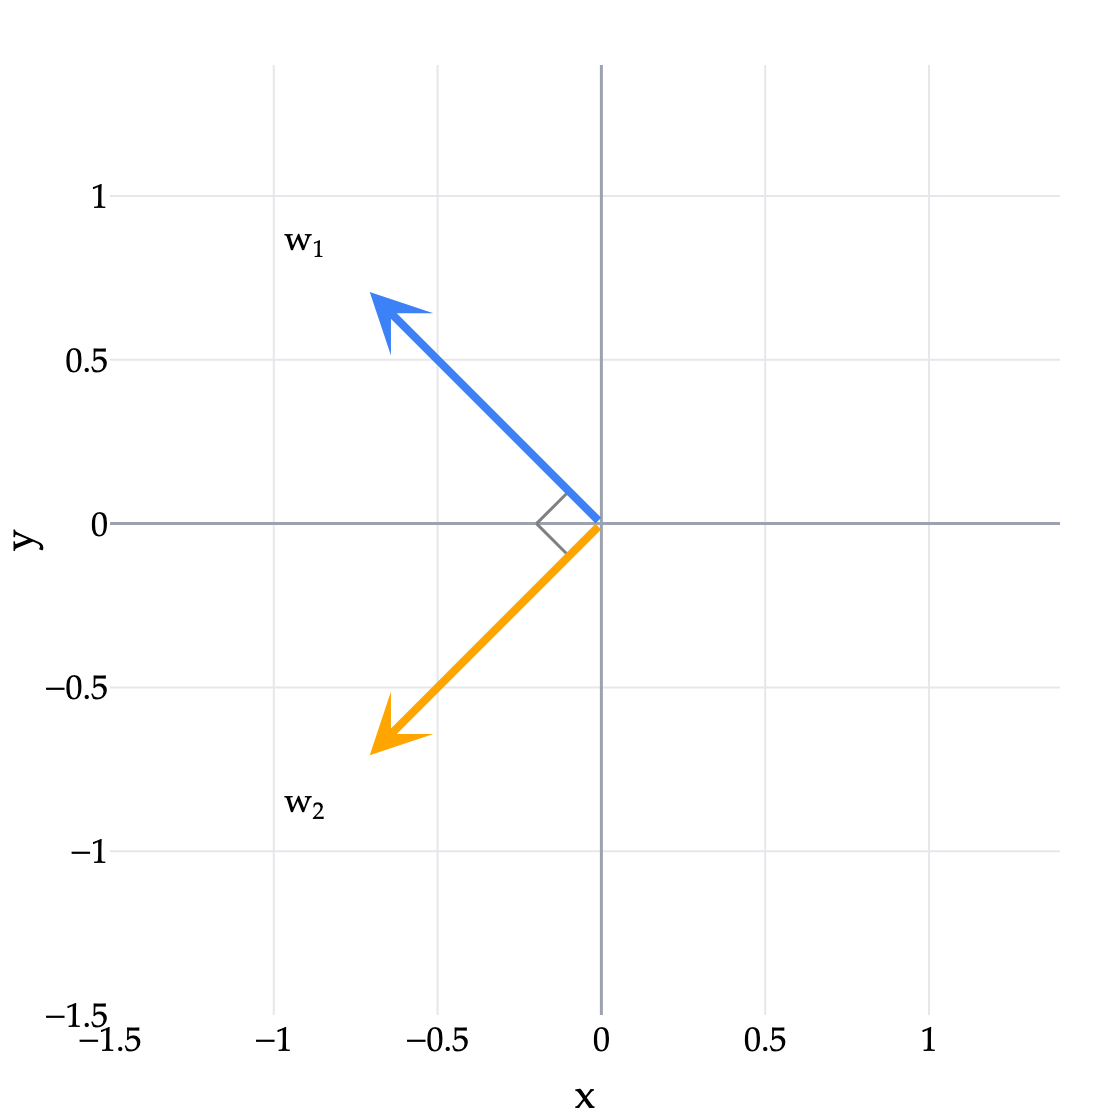

In [5]:
fig=base2((-1.5,1.4),(-1.5,1.4),width=560,height=560,tick=0.5)
w1=np.array([-1,1])/np.sqrt(2); w2=np.array([-1,-1])/np.sqrt(2)
vec2(fig,w1,'w<sub>1</sub>',BLUE,dx=-0.2,dy=0.15,width=4)
vec2(fig,w2,'w<sub>2</sub>',ORANGE,dx=-0.2,dy=-0.15,width=4)
square2(fig,(0,0),w1,w2,0.14)
fig.show(scale=2)

An orthonormal basis is not unique.

**Remark.**

Note that an orthonormal basis is not unique.

## Finding coefficients using dot products

The reason orthonormal bases are useful is that it is very easy to express an
arbitrary vector in terms of an orthonormal basis.

Let $\vec u_1,\vec u_2$ be an orthonormal basis of $\mathbb{R}^2$.

Let $\vec v$ be any vector in $\mathbb{R}^2$.

Then

$$
\vec v=a\vec u_1+b\vec u_2
$$

for some scalars $a,b$. This follows by completing the rectangle in the figure below.

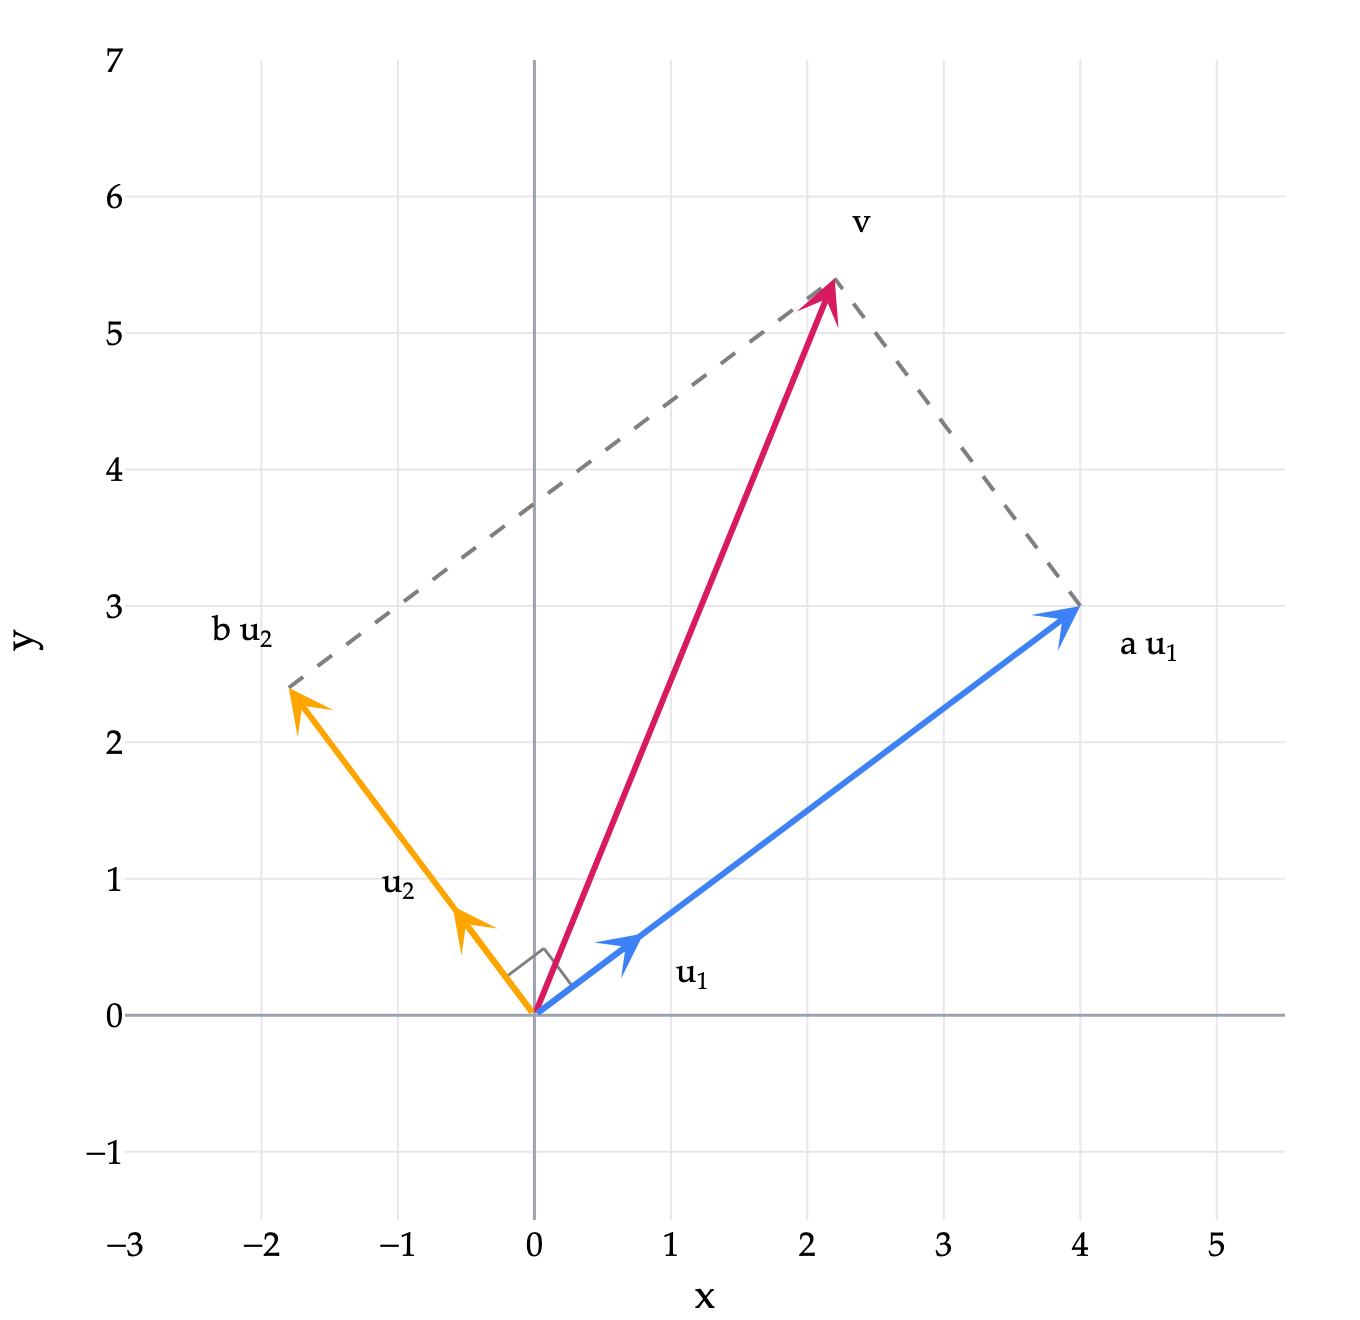

In [6]:
fig=base2((-3,5.5),(-1.5,7),width=680,height=660)
u1=np.array([4/5,3/5]); u2=np.array([-3/5,4/5])
a,b=5,3
p=a*u1; q=b*u2; v=p+q
line2(fig,p,v,'gray','dash'); line2(fig,q,v,'gray','dash')
vec2(fig,p,'a u<sub>1</sub>',BLUE,dx=0.5,dy=-0.3)
vec2(fig,q,'b u<sub>2</sub>',ORANGE,dx=-0.35,dy=0.4)
vec2(fig,v,'v',PINK,dx=0.2,dy=0.4)
square2(fig,(0,0),u1,u2,0.35)
vec2(fig,u1,'u<sub>1</sub>',BLUE,dx=0.35,dy=-0.3)
vec2(fig,u2,'u<sub>2</sub>',ORANGE,dx=-0.4,dy=0.15)
fig.show(scale=2)

The decomposition
$\vec v=a\vec u_1+b\vec u_2$ with respect to the orthonormal directions
$\vec u_1$ and $\vec u_2$.

But how do we find $a,b$?

The distributive and scalar-multiplication properties from [Chapter 1.6](../ch01/01-06.ipynb) let us isolate one coefficient at a time. Take the dot product with $\vec u_1$:

$$
\vec v\cdot \vec u_1
=
(a\vec u_1+b\vec u_2)\cdot \vec u_1
=
a(\vec u_1\cdot \vec u_1)
+
b(\vec u_2\cdot \vec u_1).
$$

Since $\vec u_1$ is a unit vector,

$$
\vec u_1\cdot \vec u_1=1.
$$

Since $\vec u_1$ and $\vec u_2$ are orthogonal,

$$
\vec u_2\cdot \vec u_1=0.
$$

Therefore

$$
\vec v\cdot \vec u_1=a.
$$

Similarly,

$$
b=\vec v\cdot \vec u_2.
$$

So

$$
\vec v
=
(\vec v\cdot \vec u_1)\vec u_1
+
(\vec v\cdot \vec u_2)\vec u_2.
$$

## Representing the same vector in different bases

Let

$$
\vec v=
\begin{bmatrix}
7\\
5
\end{bmatrix}.
$$

### Using the standard basis

For the standard basis

$$
(\vec e_1,\vec e_2)
=
\left(
\begin{bmatrix}
1\\
0
\end{bmatrix},
\begin{bmatrix}
0\\
1
\end{bmatrix}
\right),
$$

we have

$$
\vec v\cdot \vec e_1
=
\begin{bmatrix}
7\\
5
\end{bmatrix}
\cdot
\begin{bmatrix}
1\\
0
\end{bmatrix}
=
7,
$$

and

$$
\vec v\cdot \vec e_2
=
\begin{bmatrix}
7\\
5
\end{bmatrix}
\cdot
\begin{bmatrix}
0\\
1
\end{bmatrix}
=
5.
$$

Therefore

$$
(\vec v\cdot \vec e_1)\vec e_1
+
(\vec v\cdot \vec e_2)\vec e_2
=
7\vec e_1+5\vec e_2
=
\begin{bmatrix}
7\\
0
\end{bmatrix}
+
\begin{bmatrix}
0\\
5
\end{bmatrix}
=
\begin{bmatrix}
7\\
5
\end{bmatrix}.
$$

### Using a different orthonormal basis

Now take the orthonormal basis

$$
(\vec u_1,\vec u_2)
=
\left(
\begin{bmatrix}
\frac45\\[2pt]
\frac35
\end{bmatrix},
\begin{bmatrix}
-\frac35\\[2pt]
\frac45
\end{bmatrix}
\right).
$$

Then

$$
\vec v\cdot \vec u_1
=
\begin{bmatrix}
7\\
5
\end{bmatrix}
\cdot
\begin{bmatrix}
\frac45\\[2pt]
\frac35
\end{bmatrix}
=
\frac{28}{5}+\frac{15}{5}
=
\frac{43}{5}.
$$

Also,

$$
\vec v\cdot \vec u_2
=
\begin{bmatrix}
7\\
5
\end{bmatrix}
\cdot
\begin{bmatrix}
-\frac35\\[2pt]
\frac45
\end{bmatrix}
=
-\frac{21}{5}+\frac{20}{5}
=
-\frac15.
$$

So

$$
\vec v
=
\frac{43}{5}\vec u_1
-
\frac15 \vec u_2.
$$

### Using another orthonormal basis

Continuing the example, suppose

$$
(\vec w_1,\vec w_2)
=
\left(
\begin{bmatrix}
-\frac{1}{\sqrt{2}}\\[2pt]
\frac{1}{\sqrt{2}}
\end{bmatrix},
\begin{bmatrix}
-\frac{1}{\sqrt{2}}\\[2pt]
-\frac{1}{\sqrt{2}}
\end{bmatrix}
\right).
$$

Let

$$
\vec v=
\begin{bmatrix}
7\\
5
\end{bmatrix}.
$$

Then

$$
\vec v\cdot \vec w_1
=
\begin{bmatrix}
7\\
5
\end{bmatrix}
\cdot
\begin{bmatrix}
-\frac{1}{\sqrt{2}}\\[2pt]
\frac{1}{\sqrt{2}}
\end{bmatrix}
=
-\frac{7}{\sqrt{2}}+\frac{5}{\sqrt{2}}
=
-\frac{2}{\sqrt{2}}
=
-\sqrt{2}.
$$

Also,

$$
\vec v\cdot \vec w_2
=
\begin{bmatrix}
7\\
5
\end{bmatrix}
\cdot
\begin{bmatrix}
-\frac{1}{\sqrt{2}}\\[2pt]
-\frac{1}{\sqrt{2}}
\end{bmatrix}
=
-\frac{7}{\sqrt{2}}-\frac{5}{\sqrt{2}}
=
-\frac{12}{\sqrt{2}}
=
-6\sqrt{2}.
$$

So

$$
\vec v
=
-\sqrt{2}\,\vec w_1
-
6\sqrt{2}\,\vec w_2.
$$

The vector is the same in all three cases. Its coefficients change because we are describing it using different pairs of directions.